In [598]:
week = 11
function = 8

In [599]:
import pandas as pd
import numpy as np
import importlib

from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm
from sklearn.preprocessing import StandardScaler

import tensorflow as tf

In [600]:
import bbo_project.data_loading as data_loading
import bbo_project.data_augmentation as data_augmentation
import bbo_project.data_plotting as data_plotting

importlib.reload(data_loading)
importlib.reload(data_augmentation)
importlib.reload(data_plotting)

<module 'bbo_project.data_plotting' from 'C:\\Users\\gajones\\Desktop\\bbo_project\\src\\bbo_project\\data_plotting.py'>

In [601]:
print(f"Requested function {function} in week {week}")

print("\nData Loading")

# return path for required dataset
PROJECT_DIR, data_folder_name, week_folder_name = data_loading.get_working_week(week, function)

# load initial data
df = data_loading.load_initial_data(PROJECT_DIR, data_folder_name)
# print(f"\tloaded original data set...")

# Add updated points
df = data_loading.apply_updates(df, week, data_folder_name)

# create file structure for saving results to
results_dir = data_loading.create_results_dir(week_folder_name, data_folder_name)
print(f"\tresults will be saved to {results_dir}...")

print("\nData Preprocessing")
print("\tsetting values below numerical precision to zero")
df.loc[df["Y1"].abs() < 1e-6, "Y1"] = 0

print("\tscaling output variable")
Q3 = df["Y1"].quantile(0.75)
df["promising"] = (df["Y1"] >= Q3).astype(int)

print("\textracting input variables")
input_cols = data_loading.get_X_cols(df)

print("\tfinding points within threshold of current max")
df_fitting = data_augmentation.extract_distance_from_max(df, "Y1", input_cols, 8)

x_scaler = StandardScaler()
y_scaler = StandardScaler()

df_fitting.loc[:, "YScaled"] = y_scaler.fit_transform(df_fitting[["Y1"]])
df_fitting.loc[:, input_cols] = x_scaler.fit_transform(df_fitting[input_cols])

print("\tseparating iputs and outputs for fitting")
X = df_fitting[input_cols].to_numpy(dtype=np.float32)
y = df_fitting["YScaled"].to_numpy(dtype=np.float32).reshape(-1,1)

print(f"\n Current Max Value: {df['Y1'].max()}")

Requested function 8 in week 11

Data Loading
	Loaded initial data: function_8
	Available update files:
		1: new_data_point_wk1.csv
		2: new_data_point_wk10.csv
		3: new_data_point_wk2.csv
		4: new_data_point_wk3.csv
		5: new_data_point_wk4.csv
		6: new_data_point_wk5.csv
		7: new_data_point_wk6.csv
		8: new_data_point_wk7.csv
		9: new_data_point_wk8.csv
		10: new_data_point_wk9.csv
	Added 10 new data points.
	results will be saved to c:\Users\gajones\Desktop\bbo_project\results\plots\week_11\function_8...

Data Preprocessing
	setting values below numerical precision to zero
	scaling output variable
	extracting input variables
	finding points within threshold of current max
	separating iputs and outputs for fitting

 Current Max Value: 9.833483908


C:\Users\gajones\AppData\Local\Temp\ipykernel_27232\991066603.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fitting.loc[:, "YScaled"] = y_scaler.fit_transform(df_fitting[["Y1"]])


In [571]:
# =====================================================
# Convert data
# =====================================================

x_train = tf.convert_to_tensor(X, dtype=tf.float32)
y_train = tf.convert_to_tensor(y, dtype=tf.float32)

n_features = X.shape[1]
n_hidden = 4

# =====================================================
# Initialize weights (He initialization)
# =====================================================

W1 = tf.Variable(tf.random.normal(shape=(n_features + 1, n_hidden),stddev=np.sqrt(2 / n_features)))
W2 = tf.Variable(tf.random.normal(shape=(n_hidden, 1),stddev=np.sqrt(2 / n_hidden)))

# =====================================================
# Forward pass
# =====================================================

def forward_pass(x):

    # Add bias column
    bias = tf.ones((tf.shape(x)[0], 1))
    x = tf.concat([x, bias], axis=1)

    hidden = tf.matmul(x, W1)
    hidden = tf.nn.relu(hidden)

    output = tf.matmul(hidden, W2)

    return output

# =====================================================
# Loss / Optimizer
# =====================================================

loss_fn = tf.keras.losses.MeanSquaredError()
optimizer = tf.keras.optimizers.SGD(learning_rate=0.05)

# =====================================================
# Training step
# =====================================================

@tf.function
def train_step(x, y):

    with tf.GradientTape() as tape:

        y_pred = forward_pass(x)
        loss = loss_fn(y, y_pred)

    gradients = tape.gradient(loss,[W1, W2])

    optimizer.apply_gradients(zip(gradients, [W1, W2]))

    return loss

Epoch 0: Loss = 1.987952
Epoch 500: Loss = 0.105000
Epoch 1000: Loss = 0.096366
Epoch 1500: Loss = 0.086802
Epoch 2000: Loss = 0.083902
Epoch 2500: Loss = 0.071983
Epoch 3000: Loss = 0.068745
Epoch 3500: Loss = 0.069078
Epoch 4000: Loss = 0.067420
Epoch 4500: Loss = 0.060479
Epoch 5000: Loss = 0.059720
Epoch 5500: Loss = 0.057227
Epoch 6000: Loss = 0.055653
Epoch 6500: Loss = 0.053859
Epoch 7000: Loss = 0.052665
Epoch 7500: Loss = 0.054903
Epoch 8000: Loss = 0.050354
Epoch 8500: Loss = 0.050799
Epoch 9000: Loss = 0.049433
Epoch 9500: Loss = 0.052477
Epoch 10000: Loss = 0.049818
Epoch 10500: Loss = 0.047890
Epoch 11000: Loss = 0.049027
Epoch 11500: Loss = 0.049009
Epoch 12000: Loss = 0.048687
Epoch 12500: Loss = 0.047261
Epoch 13000: Loss = 0.047676
Epoch 13500: Loss = 0.046565
Epoch 14000: Loss = 0.046976
Epoch 14500: Loss = 0.047242
Epoch 15000: Loss = 0.047458
Epoch 15500: Loss = 0.046827
Epoch 16000: Loss = 0.051200
Epoch 16500: Loss = 0.049689
Epoch 17000: Loss = 0.051529
Epoch 175

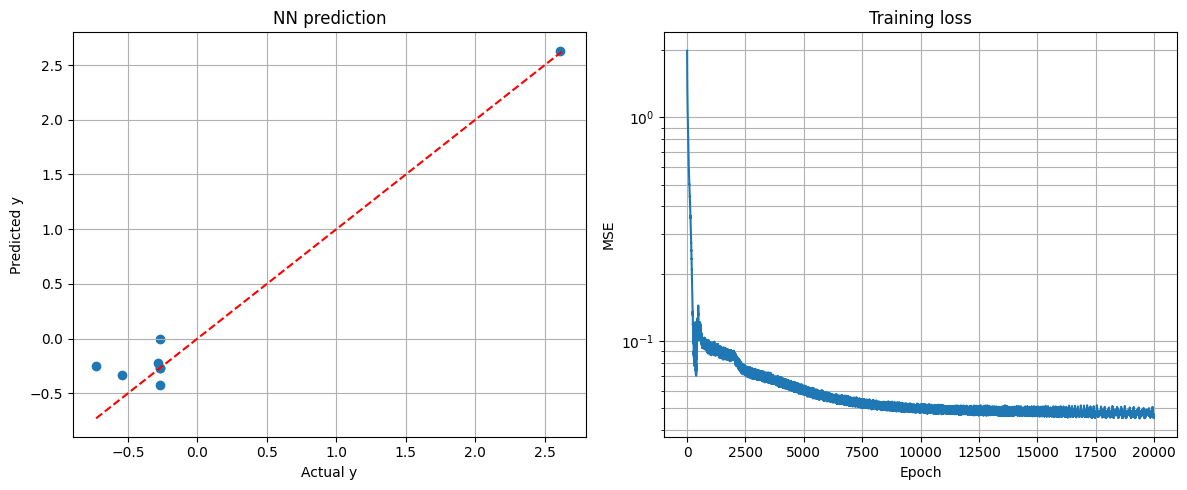

In [572]:
epochs = 20000
loss_history = []

for epoch in range(epochs):

    loss = train_step(x_train, y_train)

    loss_history.append(loss.numpy())

    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss = {loss.numpy():.6f}")

y_pred = forward_pass(X).numpy()

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(12, 5))

ax1.scatter(y.flatten(),y_pred.flatten())

lims = [min(y.min(), y_pred.min()),max(y.max(), y_pred.max())]

ax1.plot(lims,lims,"r--")

ax1.set_xlabel("Actual y")
ax1.set_ylabel("Predicted y")
ax1.set_title("NN prediction")
ax1.grid(True)

# ---------------------
# Loss curve (log scale)
# ---------------------

ax2.plot(loss_history)

ax2.set_yscale("log")      # logarithmic y-axis

ax2.set_xlabel("Epoch")
ax2.set_ylabel("MSE")
ax2.set_title("Training loss")
ax2.grid(True, which="both")

plt.tight_layout()
plt.show()

In [573]:
print(f"Calaculating Convex Hull around chosen data set...")
hull, points_hull = data_augmentation.compute_convex_hull(df_fitting[input_cols])
internal_points = data_augmentation.seed_convex_hull(points_hull, hull)

y_test = forward_pass(internal_points).numpy()
best_index = np.argmax(y_test)

x_max = internal_points[best_index]
y_max = y_test[best_index]

# undo scaling
x_max_original = x_scaler.inverse_transform(
    x_max.reshape(1, -1)
)

y_max_original = y_scaler.inverse_transform(
    y_max.reshape(1, -1)
)

print("Maximum location:")
print(x_max_original)

print("Maximum value:")
print(y_max_original,df["Y1"].max())

Calaculating Convex Hull around chosen data set...
Maximum location:
[[0.51254252 0.60464263]]
Maximum value:
[[0.08425277]] 0.03789134


(<Figure size 500x250 with 2 Axes>,
 array([[<Axes: xlabel='X1', ylabel='YScaled'>, <Axes: xlabel='X2'>]],
       dtype=object))

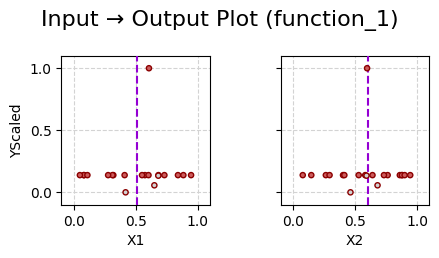

In [574]:
best_point_dict = {col: val for col, val in zip(input_cols, x_max_original[0])}

X = df[input_cols].to_numpy()

df["YScaled"] = data_augmentation.minmax_scale(df["Y1"])
Y = df["YScaled"].to_numpy()
Y = np.asarray(Y).reshape(-1, 1)

try:
    Z = df["promising"].to_numpy().reshape(-1, 1)
except:
    Z = np.zeros(len(Y)) 

data_plotting.domain_io_plot(data_folder_name, results_dir, input_cols, ["YScaled"], X, Y, Z, next_point=best_point_dict)

In [575]:
s = "-".join(f"{v:.6f}" for v in best_point_dict.values())
print(s)

0.512543-0.604643
